<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64

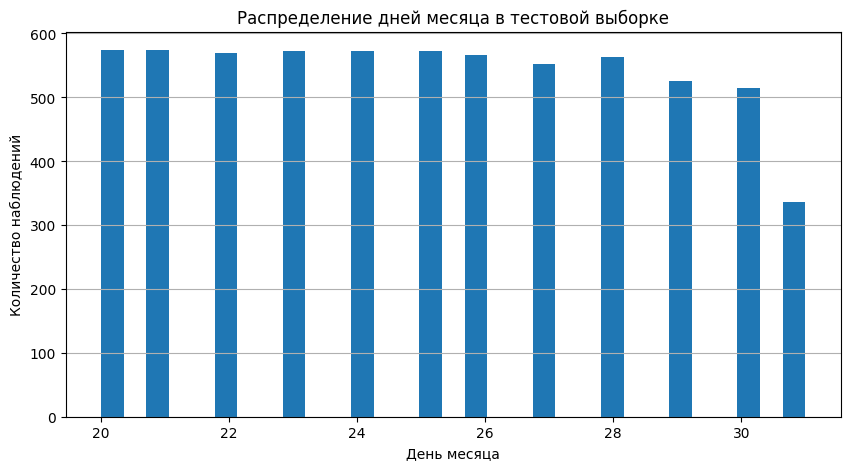

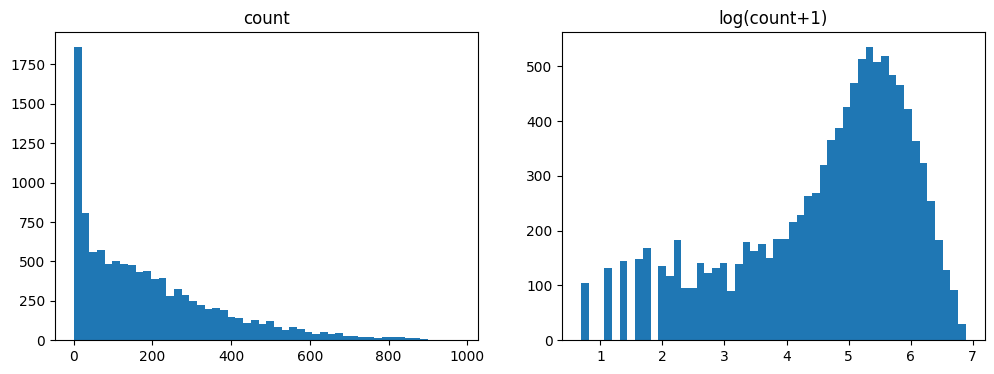

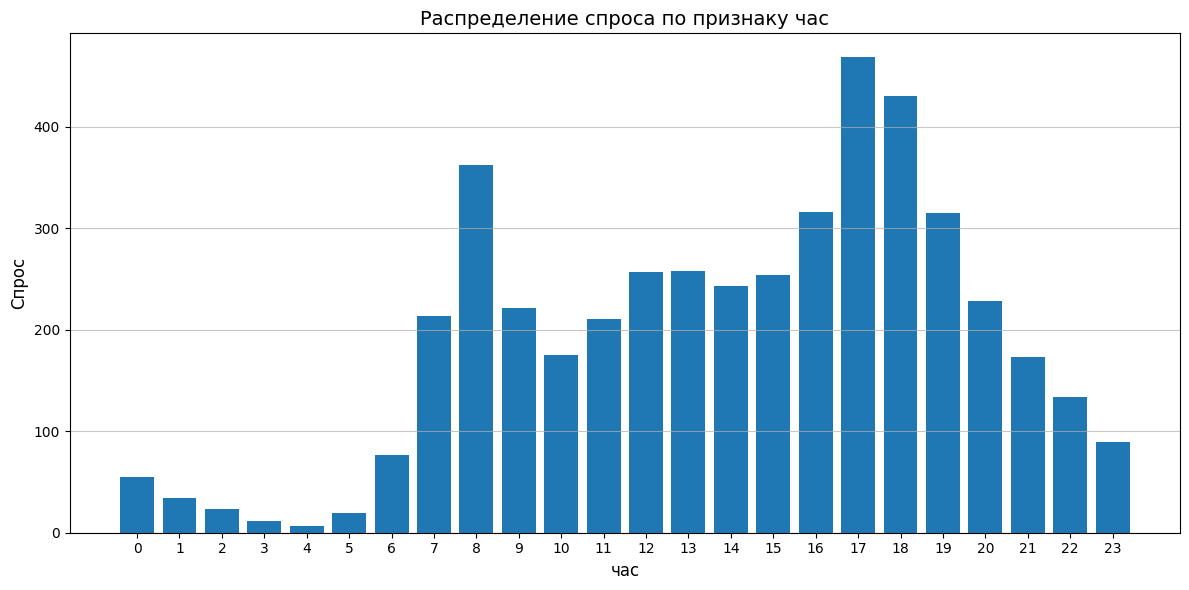

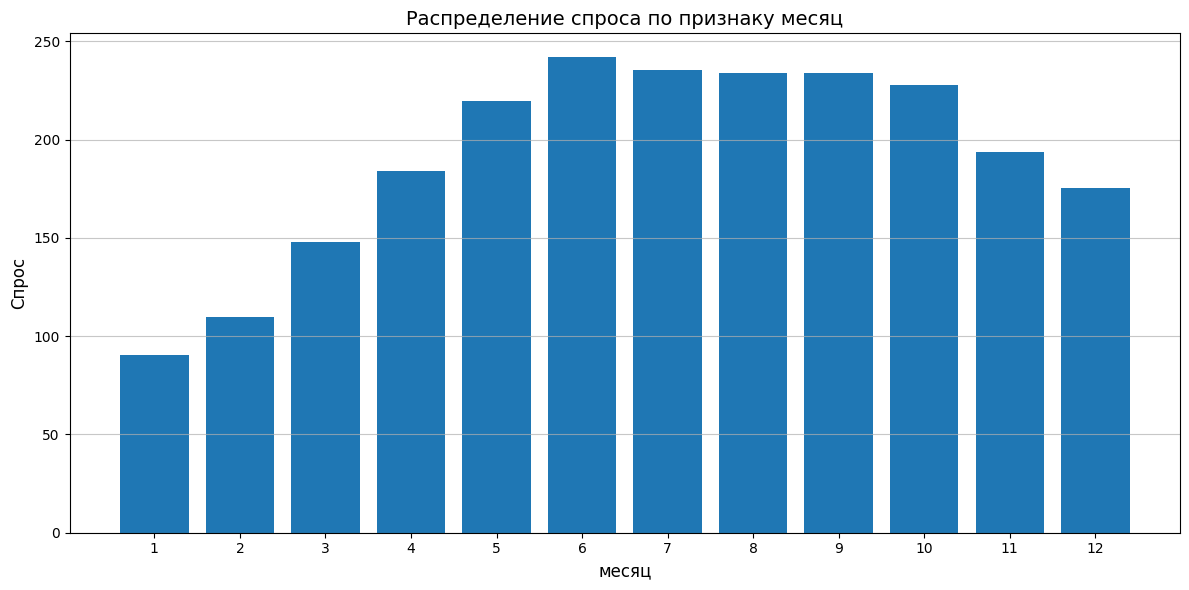

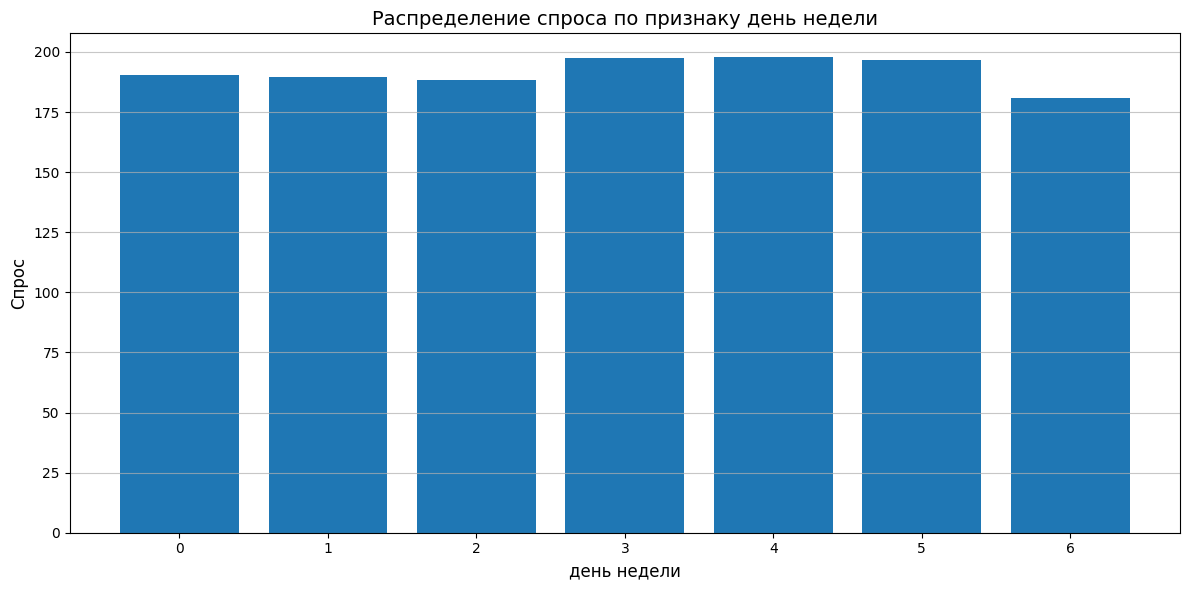

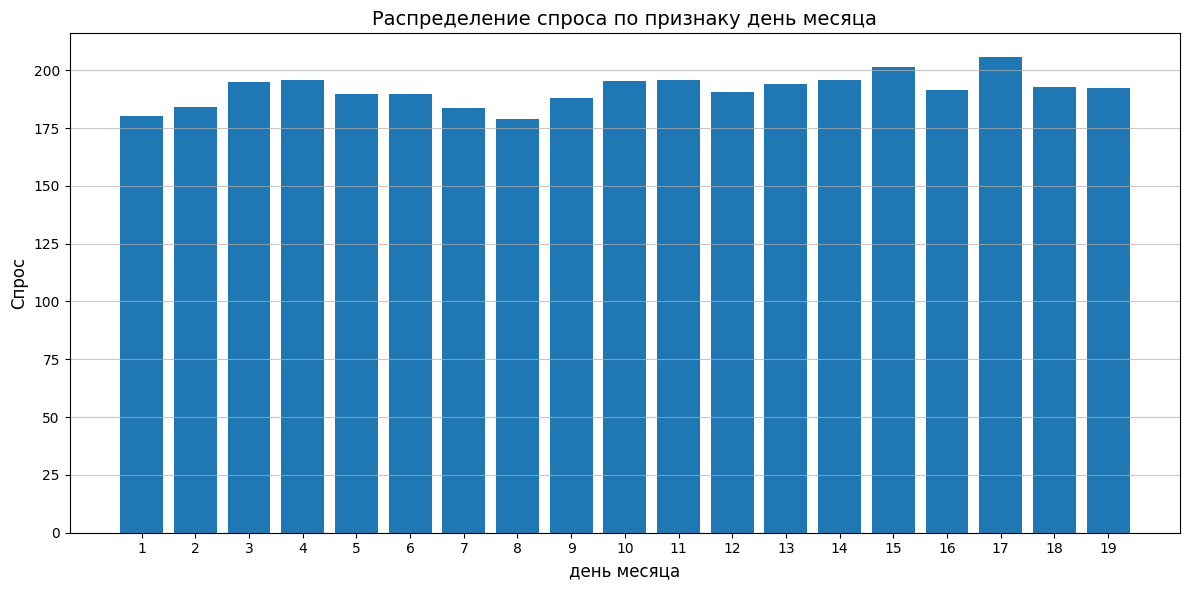

<Axes: title={'center': 'диаграмма распределения humidity%'}, ylabel='Frequency'>

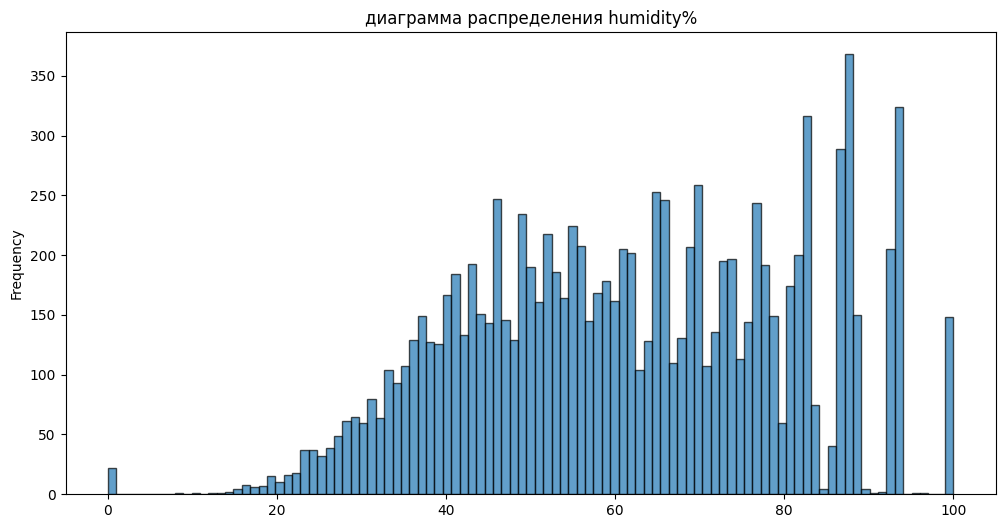

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

train = pd.read_csv(r'csvs\train.csv')
test = pd.read_csv(r'csvs\test.csv')
test["datetime"] = pd.to_datetime(test["datetime"])
test['day'] = test['datetime'].dt.day

print(train.info())
print()
print(test.info())
print()
print(train.describe())
print()

plt.figure(figsize=(10, 5))
plt.hist(test['day'], bins=31)
plt.title('Распределение дней месяца в тестовой выборке')
plt.xlabel('День месяца')
plt.ylabel('Количество наблюдений')
plt.grid(axis='y')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['count'], bins=50)
axes[0].set_title('count')
axes[1].hist(np.log1p(train['count']), bins=50)
axes[1].set_title('log(count+1)')


def show_hist(df, feature, name):
    hour_count = train_data.groupby(feature)['count'].mean().reset_index()

    plt.figure(figsize=(12, 6))
    plt.bar(hour_count[feature], hour_count['count'], width=0.8)
    plt.xlabel(name, fontsize=12)
    plt.ylabel('Спрос', fontsize=12)
    plt.title(f'Распределение спроса по признаку {name}', fontsize=14)
    plt.xticks(hour_count[feature])
    plt.grid(axis='y', alpha=0.7)
    plt.tight_layout()
    plt.show()

train_data = pd.read_csv(r"csvs\train.csv")

train_data["datetime"] = pd.to_datetime(train_data["datetime"])
train_data['hour'] = train_data['datetime'].dt.hour
train_data['month'] = train_data['datetime'].dt.month
train_data['weekday'] = train_data['datetime'].dt.weekday
train_data['day'] = train_data['datetime'].dt.day
show_hist(train_data, 'hour', 'час')
show_hist(train_data, 'month', 'месяц')
show_hist(train_data, 'weekday', 'день недели')
show_hist(train_data, 'day', 'день месяца')
train_data['humidity'].plot.hist(bins=101, edgecolor='black', alpha=0.7, figsize=(12,6), title="диаграмма распределения humidity%")

График сохранен в figures/casual_vs_registered.pdf


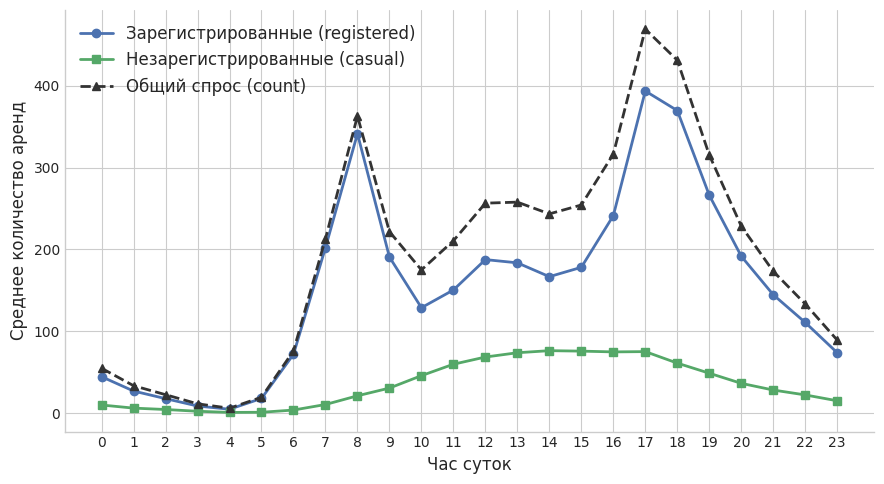

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

train = pd.read_csv("csvs/train.csv")

train["datetime"] = pd.to_datetime(train["datetime"])
train["hour"] = train["datetime"].dt.hour

hourly_avg = train.groupby("hour")[["casual", "registered", "count"]].mean()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(hourly_avg.index, hourly_avg["registered"], marker="o", linewidth=2, 
        label="Зарегистрированные (registered)", color="#4C72B0")
ax.plot(hourly_avg.index, hourly_avg["casual"], marker="s", linewidth=2, 
        label="Незарегистрированные (casual)", color="#55A868")

ax.plot(hourly_avg.index, hourly_avg["count"], marker="^", linewidth=2, 
        linestyle="--", label="Общий спрос (count)", color="#333333")

ax.set_xlabel("Час суток")
ax.set_ylabel("Среднее количество аренд")
ax.set_xticks(range(0, 24))
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("figures/casual_vs_registered.pdf", bbox_inches="tight")

print("График сохранен в figures/casual_vs_registered.pdf")

График сохранен в figures/hour_vs_workingday.pdf


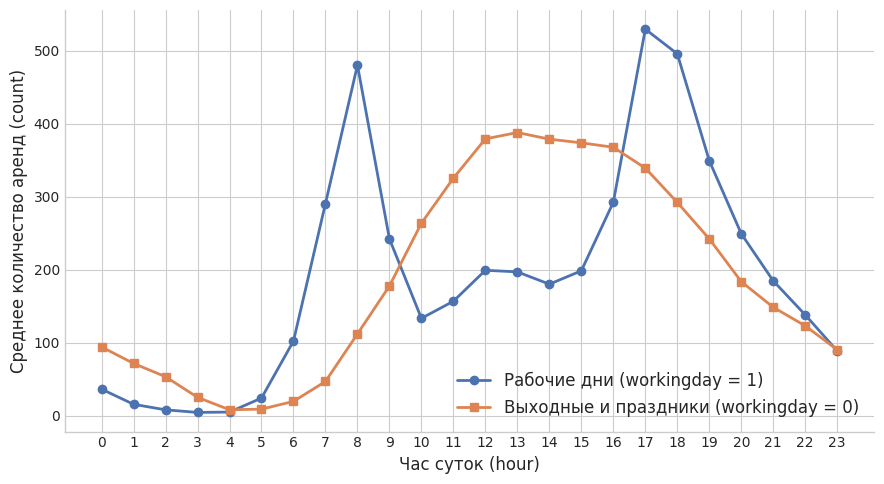

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

train = pd.read_csv(r"csvs\train.csv")

train["datetime"] = pd.to_datetime(train["datetime"])
train["hour"] = train["datetime"].dt.hour

agg_data = train.groupby(['hour', 'workingday'])['count'].mean().unstack()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(agg_data.index, agg_data[1], marker='o', linewidth=2, 
        label="Рабочие дни (workingday = 1)", color="#4C72B0")

ax.plot(agg_data.index, agg_data[0], marker='s', linewidth=2, 
        label="Выходные и праздники (workingday = 0)", color="#DD8452")

ax.set_xlabel("Час суток (hour)")
ax.set_ylabel("Среднее количество аренд (count)")
ax.set_xticks(range(0, 24))
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("figures/eda/hour_vs_workingday.pdf", bbox_inches="tight")

print("График сохранен в figures/hour_vs_workingday.pdf")

C:\Users\Home\AppData\Local\Temp\ipykernel_18840\435556177.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="month", y="count", data=train, palette="viridis", ax=ax)


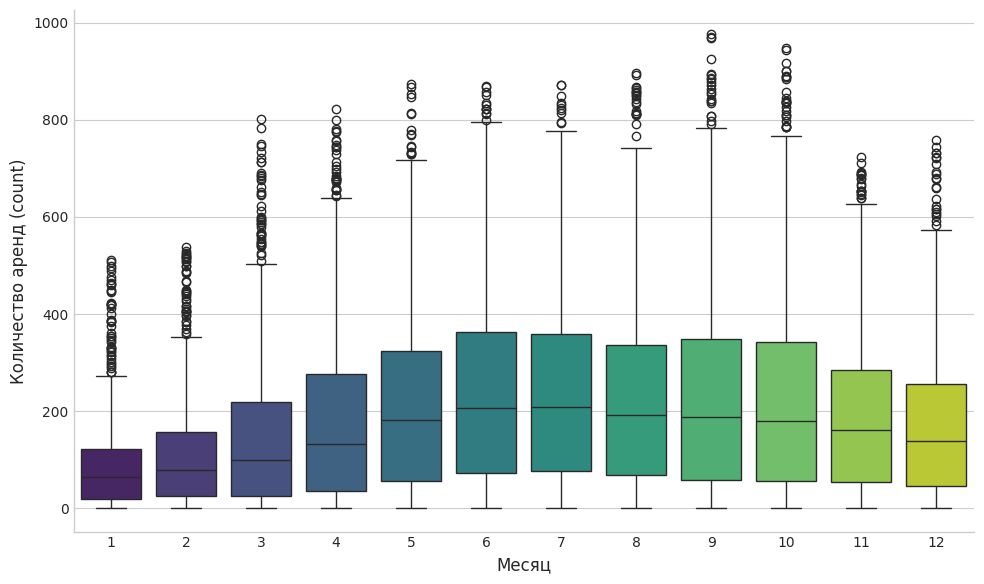

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
train = pd.read_csv("csvs/train.csv")
train["datetime"] = pd.to_datetime(train["datetime"])
train["month"] = train["datetime"].dt.month

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="month", y="count", data=train, palette="viridis", ax=ax)

ax.set_xlabel("Месяц")
ax.set_ylabel("Количество аренд (count)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("figures/eda/monthly_distribution.pdf", bbox_inches="tight")

C:\Users\Home\AppData\Local\Temp\ipykernel_18840\1973032595.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="weather", y="count", data=train, ax=axes[0], palette="Blues")


График сохранен в figures/weather_and_temp.pdf


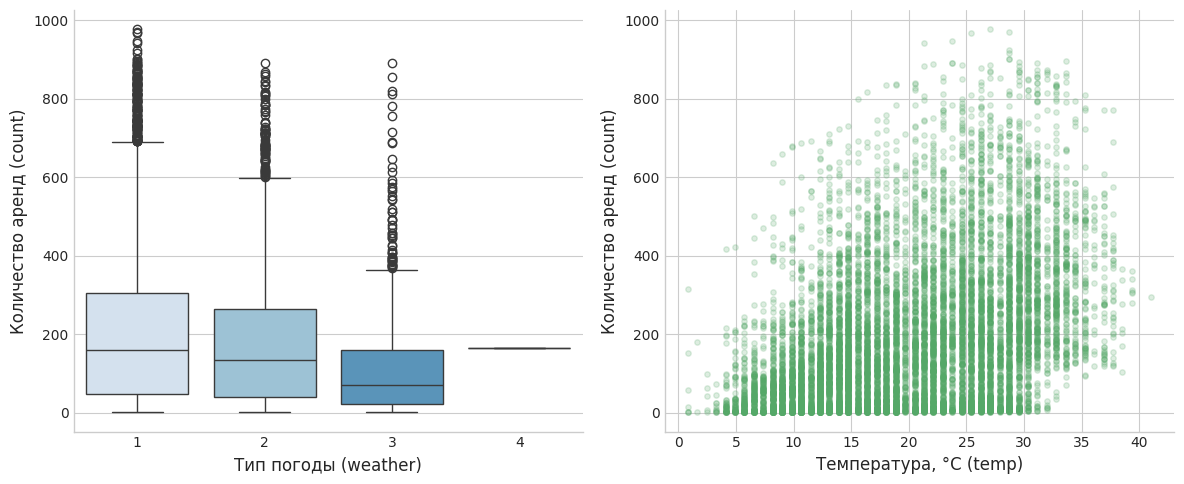

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
train = pd.read_csv("csvs/train.csv")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="weather", y="count", data=train, ax=axes[0], palette="Blues")
axes[0].set_xlabel("Тип погоды (weather)")
axes[0].set_ylabel("Количество аренд (count)")

axes[1].scatter(train["temp"], train["count"], alpha=0.2, color="#55A868", s=15)
axes[1].set_xlabel("Температура, °C (temp)")
axes[1].set_ylabel("Количество аренд (count)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("figures/weather_and_temp.pdf", bbox_inches="tight")

print("График сохранен в figures/weather_and_temp.pdf")

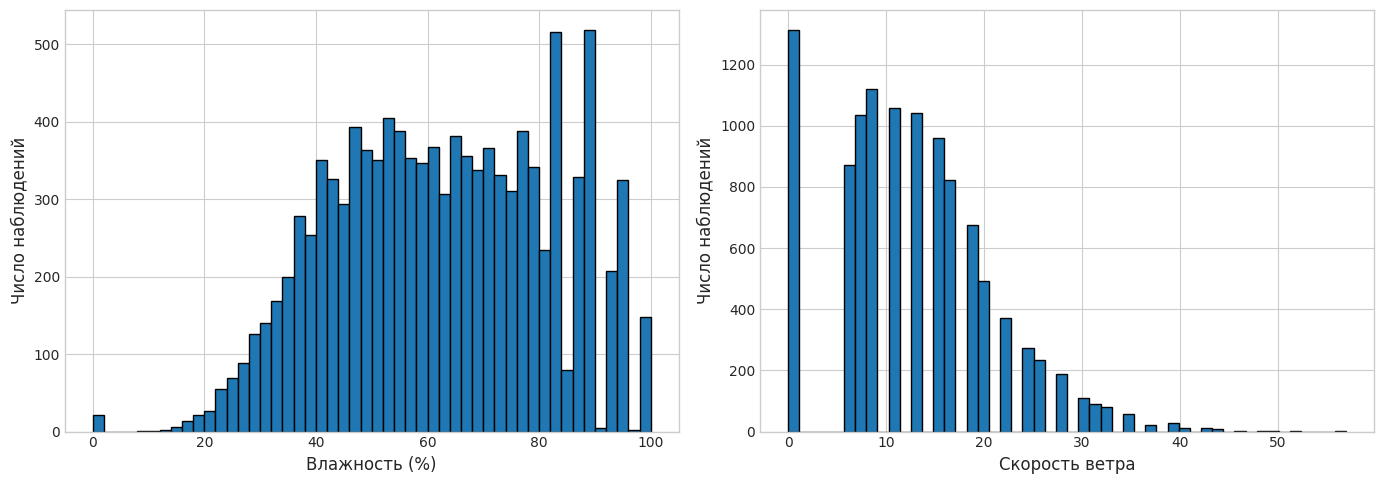

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['humidity'], bins=50, edgecolor='black')
axes[0].set_xlabel('Влажность (%)')
axes[0].set_ylabel('Число наблюдений')

axes[1].hist(train['windspeed'], bins=50, edgecolor='black')
axes[1].set_xlabel('Скорость ветра')
axes[1].set_ylabel('Число наблюдений')

plt.tight_layout()
plt.savefig('figures/eda/humidity_windspeed_dist.pdf')

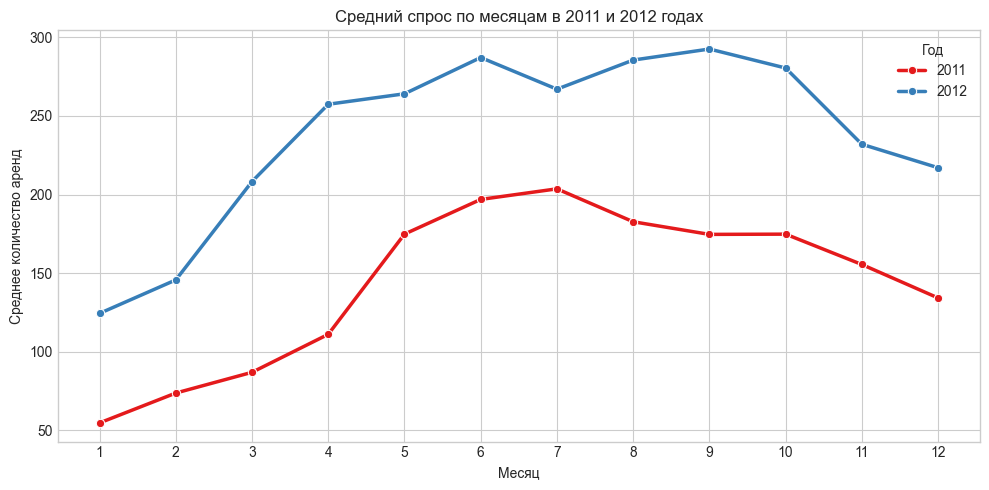

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv(r'C:\Users\Home\Downloads\bike-sharing-demand\csvs\raw\train.csv')
train['datetime'] = pd.to_datetime(train['datetime'])

train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month

monthly_year = (
    train.groupby(['year', 'month'])['count']
    .mean()
    .reset_index()
)

os.makedirs(r'C:\Users\Home\Downloads\bike-sharing-demand\figures\eda', exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_year,
    x='month',
    y='count',
    hue='year',
    marker='o',
    linewidth=2.5,
    palette='Set1'
)

plt.xlabel('Месяц')
plt.ylabel('Среднее количество аренд')
plt.xticks(range(1, 13))
plt.title('Средний спрос по месяцам в 2011 и 2012 годах')
plt.legend(title='Год')

plt.tight_layout()
plt.savefig(r'C:\Users\Home\Downloads\bike-sharing-demand\figures\eda\monthly_by_year.pdf')
plt.show()

График успешно сохранен в figures/baseline_scores.pdf


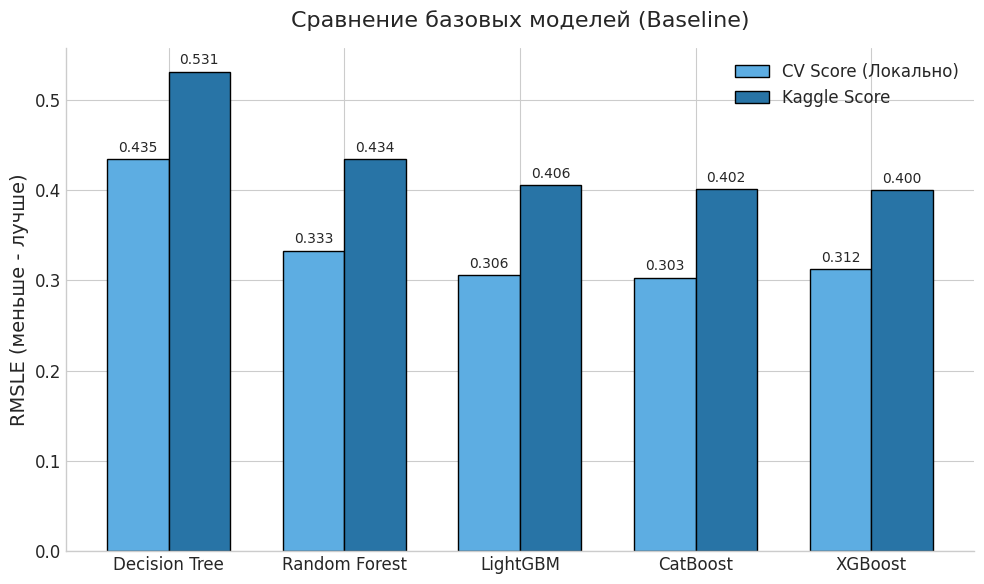

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

models = ['Decision Tree', 'Random Forest', 'LightGBM', 'CatBoost', 'XGBoost']
cv_scores = [0.434923, 0.333181, 0.305781, 0.303165, 0.312227]
kaggle_scores = [0.53149, 0.43434, 0.40615, 0.40156, 0.40043]

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams.update({'font.size': 12})

x = np.arange(len(models)) 
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, cv_scores, width, label='CV Score (Локально)', color='#5DADE2', edgecolor='black')
rects2 = ax.bar(x + width/2, kaggle_scores, width, label='Kaggle Score', color='#2874A6', edgecolor='black')

ax.set_ylabel('RMSLE (меньше - лучше)', fontsize=14)
ax.set_title('Сравнение базовых моделей (Baseline)', fontsize=16, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=12)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

os.makedirs('figures', exist_ok=True)
plt.tight_layout()
plt.savefig('figures/baseline_scores.pdf')
print("График успешно сохранен в figures/baseline_scores.pdf")
plt.show()